Otimização de Estoque: Com a lista dos produtos mais e menos vendidos, poderemos ajustar nossas compras, reduzir custos com armazenamento e evitar a perda de vendas por falta de produto.

Marketing Direcionado e Eficaz: Sabendo quais categorias e regiões são mais lucrativas, a equipe de marketing poderá criar campanhas segmentadas, aumentando o retorno sobre o investimento (ROI).

Planejamento Estratégico: A visualização das tendências mensais permitirá um melhor planejamento financeiro, promocional e de recursos, antecipando períodos de alta e baixa demanda.

Decisões Baseadas em Dados: Substituiremos a intuição por dados concretos, criando uma cultura orientada a dados que impulsionará o crescimento sustentável do negócio.

- O que vender? Identificar os produtos de maior sucesso para otimizar nosso portfólio e estoque.
Onde focar? Compreender quais categorias de produtos geram a maior parte da nossa receita.

- Quando agir? Analisar a performance de vendas ao longo do tempo para identificar tendências, picos e sazonalidades.

- Para onde expandir? Mapear a distribuição geográfica de nossas vendas para descobrir nossos mercados mais fortes.

In [1]:
!pip install -q -U watermark

In [2]:
import pandas as pandas
import numpy as numpy
import matplotlib.pyplot as pyplot
import seaborn as seaborn
import random
from datetime import datetime, timedelta

%matplotlib inline

In [3]:
%reload_ext watermark
%watermark -a "Fequer" -v -d -t -iv

Author: Fequer

Date/Time: 2026-07-12 03:00:09

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.7.0

matplotlib: 3.10.6
numpy     : 2.3.5
pandas    : 2.3.1
seaborn   : 0.13.2



In [9]:
#Gerar dados fictícios de vendas
def gera_dados_ficticios (num_registros = 800):
    
    print(f"\nIniciando a geração de {num_registros} registros de vendas ...")
    
    produtos = {
        'Laptop Gamer': {'categoria': 'Eletrônicos', 'preco': 7500.00},
        'Mouse Led': {'categoria': 'Acessórios', 'preco': 150.00},
        'Teclado Led': {'categoria': 'Acessórios', 'preco': 250.00},
        'Mouse Vertical': {'categoria': 'Acessórios', 'preco': 250.00},
        'Teclado Mecânico': {'categoria': 'Acessórios', 'preco': 550.00},
        'Monitor Ultrawide': {'categoria': 'Eletrônicos', 'preco': 2800.00},
        'Cadeira Gamer': {'categoria': 'Móveis', 'preco': 1200.00},
        'Mesa Gamer': {'categoria': 'Móveis', 'preco': 700.00},
        'Headset 7.1': {'categoria': 'Acessórios', 'preco': 800.00},
        'Placa de Vídeo': {'categoria': 'Hardware', 'preco': 4500.00},
        'SSD 1TB': {'categoria': 'Hardware', 'preco': 600.00}
    }
    
    lista_produtos = list(produtos.keys())

    cidades_estados = {
        'São Paulo': 'SP', 
        'Rio de Janeiro': 'RJ', 
        'Belo Horizonte': 'MG',
        'Porto Alegre': 'RS', 
        'Salvador': 'BA', 
        'Curitiba': 'PR', 
        'Fortaleza': 'CE'
    }
    lista_cidades = list(cidades_estados.keys())

    dados_vendas = []

    data_inicial = datetime(2026, 1, 1)
    
    for registro in range(num_registros):
        produto_nome = random.choice(lista_produtos)
        cidade = random.choice(lista_cidades)
        quantidade = numpy.random.randint(1, 8)
        data_pedido = data_inicial + timedelta(days = int(registro/5), hours = random.randint(0, 23))
        if produto_nome in ['Mouse Vertical', 'Teclado Mecânico']:
            preco_unitario = produtos[produto_nome]['preco'] * numpy.random.uniform(0.9, 1.0)
        else:
            preco_unitario = produtos[produto_nome]['preco']
        
        dados_vendas.append({
            'ID_Pedido': 1000 + registro,
            'Data_Pedido': data_pedido,
            'Nome_Produto': produto_nome,
            'Categoria': produtos[produto_nome]['categoria'],
            'Preco_Unitario': round(preco_unitario, 2),
            'Quantidade': quantidade,
            'ID_Cliente': numpy.random.randint(100, 150),
            'Cidade': cidade,
            'Estado': cidades_estados[cidade]
        })
    print("Geração de dados concluída. \n")
    return pandas.DataFrame(dados_vendas)

In [10]:
df_vendas = gera_dados_ficticios(600)


Iniciando a geração de 600 registros de vendas ...
Geração de dados concluída. 



In [11]:
type(df_vendas)

pandas.core.frame.DataFrame

In [12]:
df_vendas.shape

(600, 9)

In [25]:
df_vendas.head(10)

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
0,1000,2026-01-01 20:00:00,Headset 7.1,Acessórios,800.00,4,114,Rio de Janeiro,RJ
1,1001,2026-01-01 21:00:00,Teclado Led,Acessórios,250.00,3,122,Fortaleza,CE
2,1002,2026-01-01 01:00:00,Placa de Vídeo,Hardware,4500.00,6,116,Curitiba,PR
3,1003,2026-01-01 12:00:00,Mesa Gamer,Móveis,700.00,7,107,Curitiba,PR
4,1004,2026-01-01 22:00:00,Teclado Led,Acessórios,250.00,1,127,Curitiba,PR
5,1005,2026-01-02 10:00:00,Cadeira Gamer,Móveis,1200.00,4,121,Salvador,BA
6,1006,2026-01-02 09:00:00,Cadeira Gamer,Móveis,1200.00,6,121,Belo Horizonte,MG
7,1007,2026-01-02 02:00:00,Laptop Gamer,Eletrônicos,7500.00,6,101,Rio de Janeiro,RJ
8,1008,2026-01-02 10:00:00,Headset 7.1,Acessórios,800.00,4,114,São Paulo,SP
9,1009,2026-01-02 15:00:00,Teclado Mecânico,Acessórios,536.87,6,149,Belo Horizonte,MG


In [26]:
df_vendas.tail(10)

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
590,1590,2026-04-29 00:00:00,Monitor Ultrawide,Eletrônicos,2800.00,2,106,Belo Horizonte,MG
591,1591,2026-04-29 22:00:00,Mesa Gamer,Móveis,700.00,4,141,Curitiba,PR
592,1592,2026-04-29 21:00:00,Mouse Vertical,Acessórios,244.59,1,145,São Paulo,SP
593,1593,2026-04-29 10:00:00,Cadeira Gamer,Móveis,1200.00,1,110,Rio de Janeiro,RJ
594,1594,2026-04-29 19:00:00,Mouse Vertical,Acessórios,244.63,2,119,Rio de Janeiro,RJ
595,1595,2026-04-30 23:00:00,Cadeira Gamer,Móveis,1200.00,7,145,Belo Horizonte,MG
596,1596,2026-04-30 13:00:00,Teclado Mecânico,Acessórios,503.25,3,102,São Paulo,SP
597,1597,2026-04-30 19:00:00,Mouse Vertical,Acessórios,232.44,3,143,Fortaleza,CE
598,1598,2026-04-30 18:00:00,SSD 1TB,Hardware,600.00,7,119,Rio de Janeiro,RJ
599,1599,2026-04-30 13:00:00,Headset 7.1,Acessórios,800.00,3,137,Salvador,BA


In [27]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       600 non-null    int64         
 1   Data_Pedido     600 non-null    datetime64[ns]
 2   Nome_Produto    600 non-null    object        
 3   Categoria       600 non-null    object        
 4   Preco_Unitario  600 non-null    float64       
 5   Quantidade      600 non-null    int64         
 6   ID_Cliente      600 non-null    int64         
 7   Cidade          600 non-null    object        
 8   Estado          600 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 42.3+ KB


In [29]:
df_vendas.describe(include='all')

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado
count,600.000000,600,600,600,600.000000,600.000000,600.000000,600,600
unique,NaN,NaN,11,4,NaN,NaN,NaN,7,7
top,NaN,NaN,Monitor Ultrawide,Acessórios,NaN,NaN,NaN,São Paulo,SP
freq,NaN,NaN,66,271,NaN,NaN,NaN,107,107
mean,1299.500000,2026-03-01 23:51:54,NaN,NaN,1764.203100,3.963333,124.936667,NaN,NaN
min,1000.000000,2026-01-01 01:00:00,NaN,NaN,150.000000,1.000000,100.000000,NaN,NaN
25%,1149.750000,2026-01-30 23:45:00,NaN,NaN,250.000000,2.000000,113.000000,NaN,NaN
50%,1299.500000,2026-03-01 19:30:00,NaN,NaN,700.000000,4.000000,124.000000,NaN,NaN
75%,1449.250000,2026-03-31 23:45:00,NaN,NaN,2800.000000,6.000000,137.000000,NaN,NaN
max,1599.000000,2026-04-30 23:00:00,NaN,NaN,7500.000000,7.000000,149.000000,NaN,NaN


In [42]:
df_vendas.dtypes

ID_Pedido                  int64
Data_Pedido       datetime64[ns]
Nome_Produto              object
Categoria                 object
Preco_Unitario           float64
Quantidade                 int64
ID_Cliente                 int64
Cidade                    object
Estado                    object
Faturamento              float64
Status_Entrega            object
dtype: object

In [31]:
# Conversão explícita 
df_vendas['Data_Pedido'] = pandas.to_datetime(df_vendas['Data_Pedido'])

In [34]:
# Criado coluna 'Faturamento'
df_vendas['Faturamento'] = df_vendas['Preco_Unitario'] * df_vendas['Quantidade']

In [36]:
# Criado  coluna 'Status de Entrega'
df_vendas['Status_Entrega'] = df_vendas['Estado'].apply(lambda estado: 'Rápida' if estado in ['SP', 'RJ', 'MG'] else 'Normal')

In [43]:
df_vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Pedido       600 non-null    int64         
 1   Data_Pedido     600 non-null    datetime64[ns]
 2   Nome_Produto    600 non-null    object        
 3   Categoria       600 non-null    object        
 4   Preco_Unitario  600 non-null    float64       
 5   Quantidade      600 non-null    int64         
 6   ID_Cliente      600 non-null    int64         
 7   Cidade          600 non-null    object        
 8   Estado          600 non-null    object        
 9   Faturamento     600 non-null    float64       
 10  Status_Entrega  600 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 51.7+ KB


In [63]:
df_vendas.head()

,ID_Pedido,Data_Pedido,Nome_Produto,Categoria,Preco_Unitario,Quantidade,ID_Cliente,Cidade,Estado,Faturamento,Status_Entrega,Mes
0,1000,2026-01-01 20:00:00,Headset 7.1,Acessórios,800.0,4,114,Rio de Janeiro,RJ,3200.0,Rápida,2026-01
1,1001,2026-01-01 21:00:00,Teclado Led,Acessórios,250.0,3,122,Fortaleza,CE,750.0,Normal,2026-01
2,1002,2026-01-01 01:00:00,Placa de Vídeo,Hardware,4500.0,6,116,Curitiba,PR,27000.0,Normal,2026-01
3,1003,2026-01-01 12:00:00,Mesa Gamer,Móveis,700.0,7,107,Curitiba,PR,4900.0,Normal,2026-01
4,1004,2026-01-01 22:00:00,Teclado Led,Acessórios,250.0,1,127,Curitiba,PR,250.0,Normal,2026-01


In [64]:
# Agrupa por Nome, Soma a quantidade e ordena. Para encontrar os mais vendidos

top_10_produtos = df_vendas.groupby('Nome_Produto')['Quantidade'].sum().sort_values(ascending = False).head(10)
top_10_produtos

Nome_Produto
Monitor Ultrawide    259
Mouse Vertical       245
Laptop Gamer         237
Mouse Led            225
Mesa Gamer           220
Placa de Vídeo       215
Cadeira Gamer        207
SSD 1TB              199
Teclado Mecânico     196
Headset 7.1          192
Name: Quantidade, dtype: int64

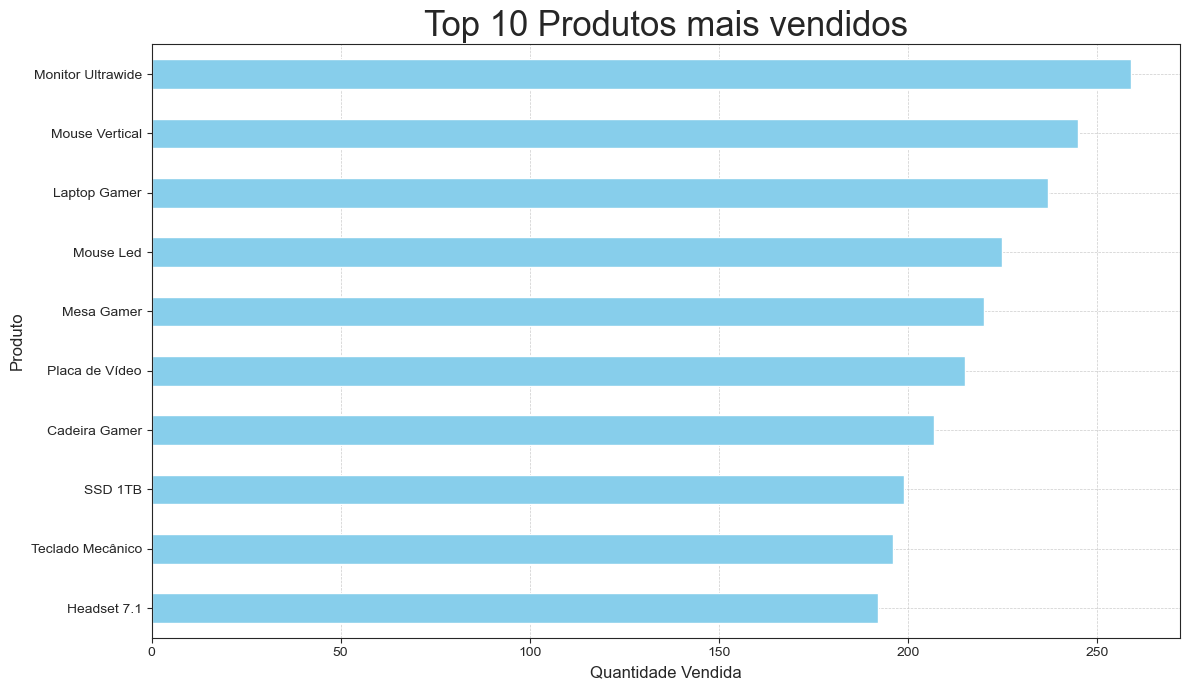

In [78]:
#andas as pd
#numpy as np
#yplot as plt
#seaborn as sns

# Definindo um estilo para o gráfico
seaborn.set_style("ticks")

# Cria o figura e os eixos
pyplot.figure(figsize = (12, 7))

# Cria o gráfico de barras horizontais
top_10_produtos.sort_values(ascending = True).plot(kind = 'barh', color = 'skyblue')

pyplot.title('Top 10 Produtos mais vendidos', fontsize = 25)
pyplot.xlabel('Quantidade Vendida', fontsize = 12)
pyplot.ylabel('Produto', fontsize = 12)
pyplot.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)

pyplot.tight_layout()
pyplot.show()

In [58]:
df_vendas['Mes'] = df_vendas['Data_Pedido'].dt.to_period('M')

In [62]:
faturamento_mensal = df_vendas.groupby('Mes')['Faturamento'].sum()
faturamento_mensal.index = faturamento_mensal.index.strftime('%Y-%m')
faturamento_mensal.map('R$ {:,.2f}'.format)

Mes
2026-01    R$ 1,147,816.59
2026-02    R$ 1,128,085.42
2026-03    R$ 1,134,929.68
2026-04      R$ 975,027.90
Name: Faturamento, dtype: object

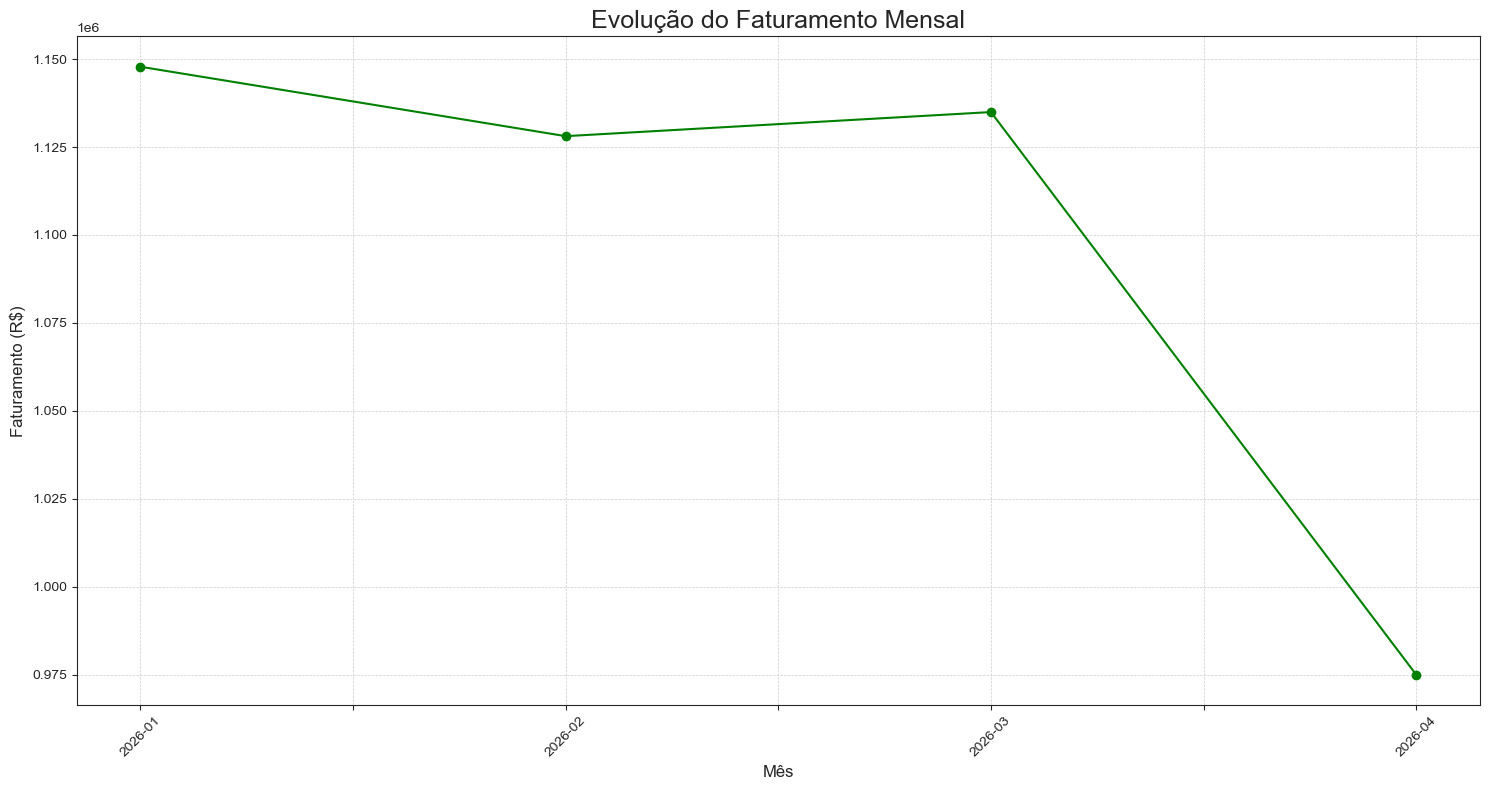

In [79]:
pyplot.figure(figsize = (15,8))
faturamento_mensal.plot(kind = 'line', marker = 'o', linestyle = '-', color ='green')
pyplot.title('Evolução do Faturamento Mensal', fontsize = 18)
pyplot.xlabel('Mês', fontsize = 12)
pyplot.ylabel('Faturamento (R$)', fontsize = 12)
pyplot.xticks(rotation = 45)
pyplot.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)
pyplot.tight_layout()
pyplot.show()

In [80]:
vendas_estado = df_vendas.groupby('Estado')['Faturamento'].sum().sort_values(ascending=False)
vendas_estado.map('R$ {:,.2f}'.format)

Estado
RS    R$ 822,811.15
CE    R$ 689,107.63
SP    R$ 646,543.10
RJ    R$ 612,870.50
BA    R$ 592,631.86
PR    R$ 525,955.17
MG    R$ 495,940.18
Name: Faturamento, dtype: object

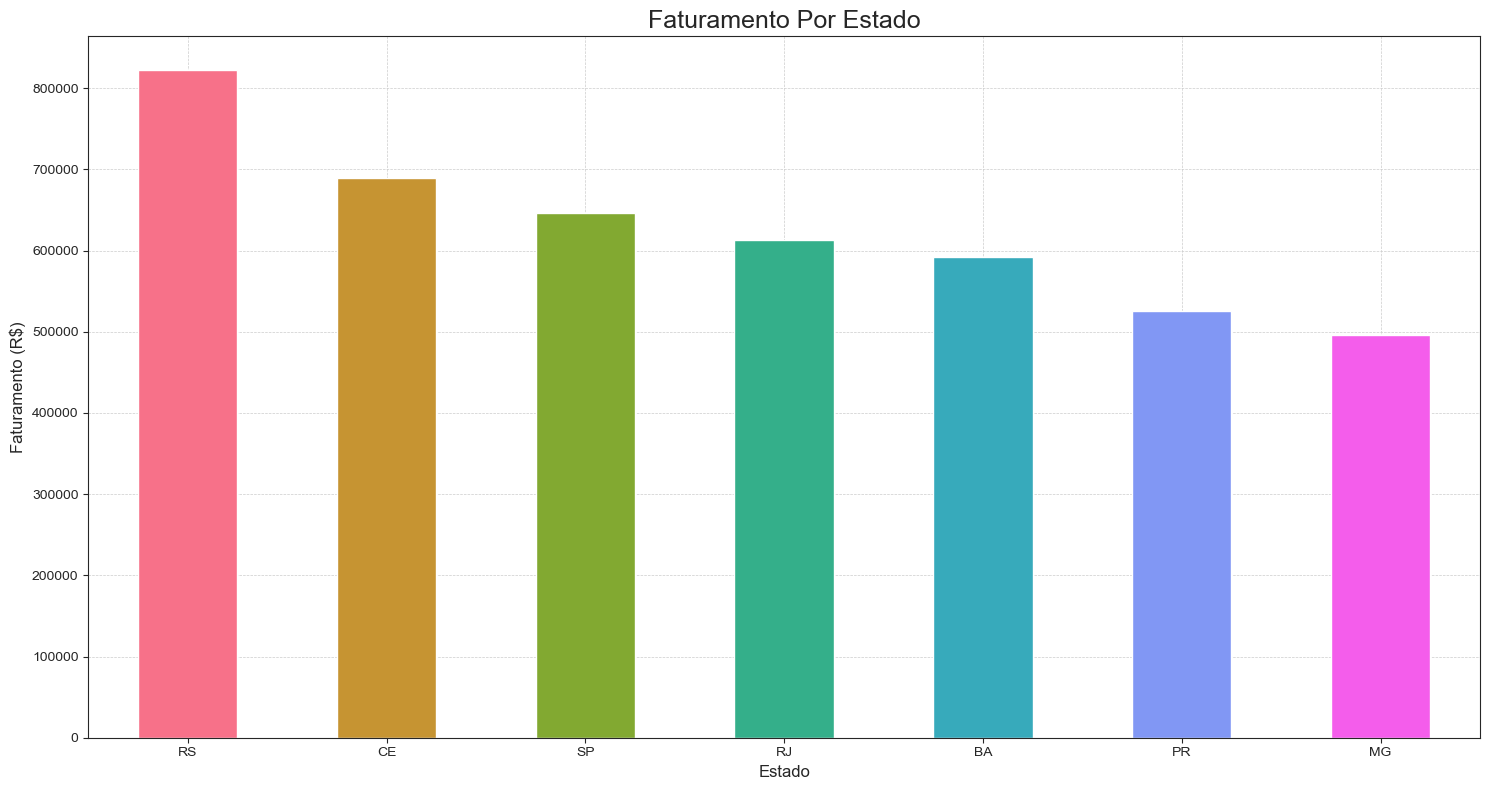

In [85]:
pyplot.figure(figsize = (15, 8))
vendas_estado.plot(kind = 'bar', color = seaborn.color_palette("husl", 7))
pyplot.title('Faturamento Por Estado', fontsize = 18)
pyplot.xlabel('Estado', fontsize = 12)
pyplot.ylabel('Faturamento (R$)', fontsize = 12)
pyplot.xticks(rotation = 0)
pyplot.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)
pyplot.tight_layout()
pyplot.show()

In [86]:
faturamento_categoria = df_vendas.groupby('Categoria')['Faturamento'].sum().sort_values(ascending=False)
faturamento_categoria.map('R$ {:,.2f}'.format)

Categoria
Eletrônicos    R$ 2,502,700.00
Hardware       R$ 1,086,900.00
Móveis           R$ 402,400.00
Acessórios       R$ 393,859.59
Name: Faturamento, dtype: object

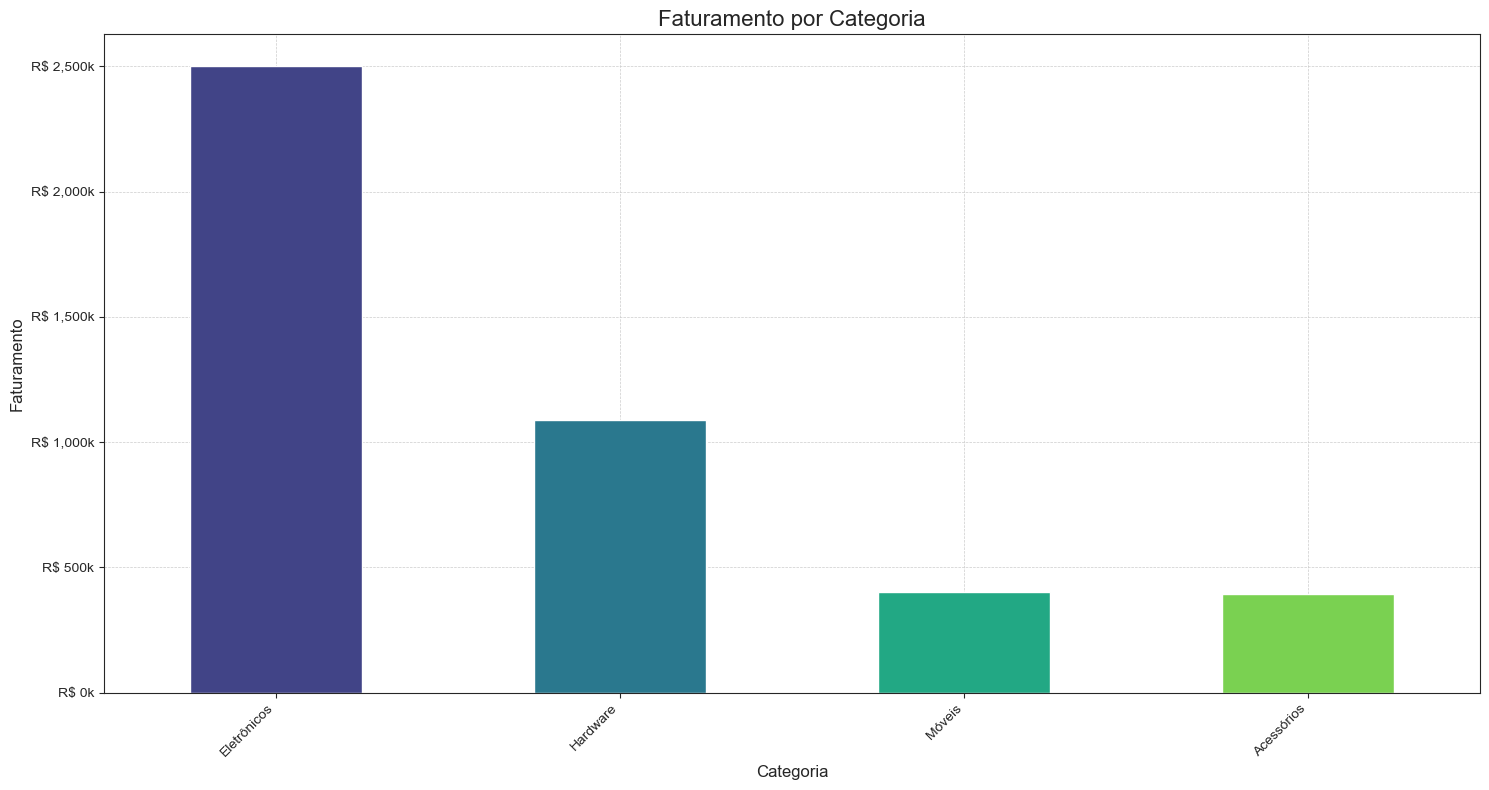

In [95]:
from matplotlib.ticker import FuncFormatter

faturamento_ordenado = faturamento_categoria.sort_values(ascending=False)

fig, ax = pyplot.subplots(figsize = (15,8))

def formatador_milhares(y, pos):
    return f'R$ {y/1000:,.0f}k'

formatter = FuncFormatter(formatador_milhares)

ax.yaxis.set_major_formatter(formatter)

faturamento_ordenado.plot(kind = 'bar', ax = ax, color = seaborn.color_palette('viridis', len(faturamento_ordenado)))

ax.set_title('Faturamento por Categoria', fontsize = 16)
ax.set_xlabel('Categoria', fontsize = 12)
ax.set_ylabel('Faturamento', fontsize = 12)


pyplot.grid(True, which = 'both', linestyle = '--', linewidth = 0.5)
pyplot.xticks(rotation = 45, ha = 'right')
pyplot.tight_layout()
pyplot.show()
